In [1]:
#load dataset 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #etiketleri one-hot encoding formatına dönüştürmek için
from sklearn.preprocessing import LabelBinarizer #veriyi standardize ede, 0 ortalamalı 1 standart sapmalı dağılıma oturtur 
from keras.models import Sequential
from keras.layers import Layer, Dense, Flatten
from keras import backend as K #keras backend API (tensor işlemlerini gerçekleştirir)
import warnings
warnings.filterwarnings("ignore")

2025-08-20 14:19:08.224879: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
iris = load_iris() #veri setini yükleme
X = iris.data
y = iris.target

#one-hot encoding 
label_binarizer = LabelBinarizer() #one hot encoding fromatına dönüştüren nesne 
y_encoded = label_binarizer.fit_transform(y)

#standardizasyon  
scaler = StandardScaler() #veriyi standartlaştırmak için nesne tanımlama
X_scaled = scaler.fit_transform(X)

#train-test split 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42) #veriyi eğitim ve test setlerine ayır

In [3]:
#radyal temelli fonksiyon (RBF) katmanı tanımlama 
class RBFLayer(Layer): #RBFLayer kerasın Layer sınıfından miras alır - inheritance
    def __init__(self, units, gamma, **kwargs):
        """
        constructor
        katmanın genel özelliklerini başlatmak için gereklidir
        """
        super(RBFLayer, self).__init__(*kwargs) #layer sınıfının init metodunu çağırır , katmaın genel özelliklerini başlatmak için gereklidir
        self.units = units #rbf katmanında gizli noron sayısı
        self.gamma = K.cast_to_floatx(gamma) #rbf fonksiyonunun yayılım parametresi, rbf duyarlılığı diyebiliriz
        
    def build(self, input_shape): 
        """
        build metodu katmanın ağırlıklarını tanımlar
        bu metot keras tarafından katman ilk defa bir input aldığında otomatik olarak çağırılır
        """
        #add_weight = kerasta eğitilebilecek ağırlıkları tanımlamak için kullanılır
        self.mu = self.add_weight(name = "mu",
                                  shape = (int(input_shape[1]), self.units),#shape =ağırlıkların boyutunu tanımlar, input_shap[1] = giriş verisinin boyutunu temsil eder. self.units = merkezlerin sayısı
        
                                           initializer = "uniform", #ağırlıkların başlangıç değeri belirlenir
                                           trainable = True #ağırlıklar eğitilebilir
                                           )
        super(RBFLayer, self).build(input_shape) #layer sınıfının build metodu çağırılarak katmanın inşası tamamlanır
        
    def call(self, inputs):
        """
        katman çağrıldığında (yani forward propagation sırasında) çalıştırılır
        bu fonksiyon girdiyi alır çıktıyı hesaplar
        """
        #inputlar ve merkezler arasındaki fark hesaplanır
        diff = K.expand_dims(inputs) - self.mu #K.expand_dims(inputs) girdiye bir boyut ekler
        l2 = K.sum(K.pow(diff,2), axis = 1) # K.pow(diff, 2) = diff in karesi alınır, K.sum() = farkların toplamı alınır ve L2 normu hesaplanabilir
        #l2 mesafesinin gamma ile çarpılması ve negatif stel bir fonksiyonunun alınması rbf değerini üretir
        res = K.exp(-1*self.gamma*l2) 
        return res
    
    def compute_output_shape(self, input_shape):
        """
        bu metot katmanın çıktısının şekli hakkında bilgi verir
        keras yardımcı fonksiyonlarından bir tanesi
        """
        return (input_shape[0], self.units) #çıktının şekli

In [4]:
#build, compile and train model
def build_model():
    model = Sequential()
    model.add(Flatten(input_shape=(4,))) #giriş verisini düzleştir
    model.add(RBFLayer(10,0.5))#RBF katmanı ekle, 10 noron, gamma=0.5
    model.add(Dense(3, activation="softmax")) #output katmanı 3 (sınıf sayısı > 2) olduğu için softmax
    
    #compile
    model.compile(optimizer="adam",
                  loss = "categorical_crossentropy",
                  metrics= ["accuracy"])
    return model

In [5]:
#model oluştur
model = build_model()

history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=4,
                    validation_split=0.3,
                    verbose=1)

2025-08-20 14:19:11.011599: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/200
21/21 [==============================] - 1s 11ms/step - loss: 1.1027 - accuracy: 0.3214 - val_loss: 1.0825 - val_accuracy: 0.3889
Epoch 2/200
21/21 [==============================] - 0s 3ms/step - loss: 1.0746 - accuracy: 0.3690 - val_loss: 1.0466 - val_accuracy: 0.5000
Epoch 3/200
21/21 [==============================] - 0s 5ms/step - loss: 1.0501 - accuracy: 0.4286 - val_loss: 1.0149 - val_accuracy: 0.5556
Epoch 4/200
21/21 [==============================] - 0s 2ms/step - loss: 1.0295 - accuracy: 0.5357 - val_loss: 0.9880 - val_accuracy: 0.5556
Epoch 5/200
21/21 [==============================] - 0s 2ms/step - loss: 1.0097 - accuracy: 0.5833 - val_loss: 0.9630 - val_accuracy: 0.5556
Epoch 6/200
21/21 [==============================] - 0s 2ms/step - loss: 0.9916 - accuracy: 0.6548 - val_loss: 0.9417 - val_accuracy: 0.5556
Epoch 7/200
21/21 [==============================] - 0s 2ms/step - loss: 0.9771 - accuracy: 0.6786 - val_loss: 0.9211 - val_accuracy: 0.5833
Epoch 8/200


In [6]:
#model evaluation 
#test veri seti ile test
loss, accuracy = model.evaluate(X_test, y_test) #test veri setindeki modelin kaybı ve doğruluğunu değerlendirir
print(f"Test Loss : {loss: .4f}, Test Accuracy : {accuracy: .4f}")

1/1 [==============================] - 0s 127ms/step - loss: 0.1291 - accuracy: 0.9667
Test Loss :  0.1291, Test Accuracy :  0.9667


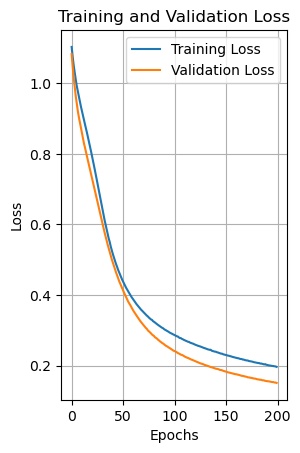

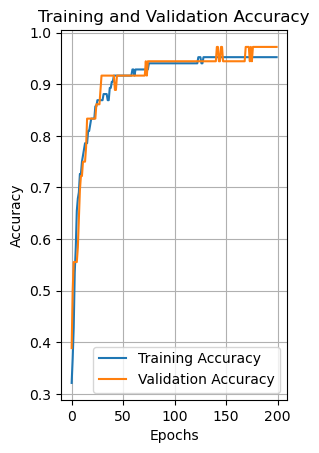

In [7]:
#history : loss ve accuracy  visualization
plt.figure()
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.figure()
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()